In [2]:
%run shared_imports.py

In [3]:
engine = make_engine("settings.toml")
session = Session(engine)

In [4]:
query = select(Round.game_mode_result, Round.map_name).filter(
    Round.start_datetime >= datetime(2023, 7, 1),
    Round.game_mode == "nuclear emergency")

df = pd.read_sql_query(query, session.connection())

In [5]:
df['result_summary'] = df['game_mode_result'].str.split(' - ', n=1).str[0]

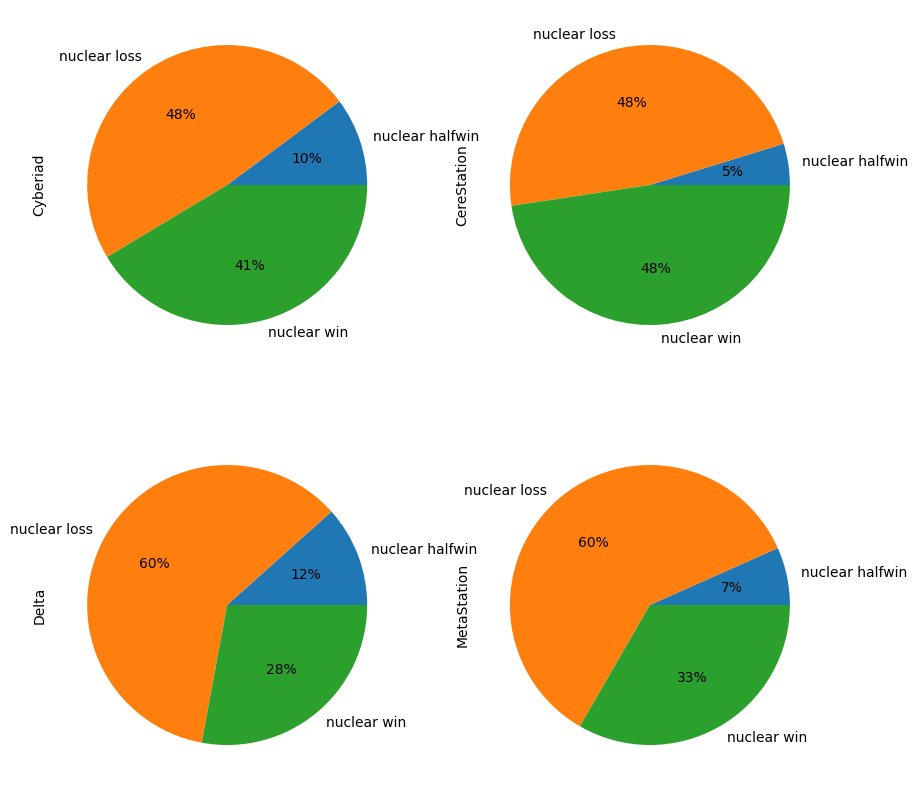

In [6]:
data = df.groupby(['result_summary', 'map_name'])['result_summary'].count().unstack(fill_value=1)
plt.figure(figsize=(10, 10))
plt.subplot2grid((2, 2), (0, 0))
data['Cyberiad'].plot(kind='pie', autopct='%1.0f%%')
plt.subplot2grid((2, 2), (0, 1))
data['CereStation'].plot(kind='pie', autopct='%1.0f%%')
plt.subplot2grid((2, 2), (1, 0))
data['Delta'].plot(kind='pie', autopct='%1.0f%%')
plt.subplot2grid((2, 2), (1, 1))
data['MetaStation'].plot(kind='pie', autopct='%1.0f%%')
plt.savefig('nukies.png')

In [ ]:
def json_to_series(text):
    keys, values = zip(*[item for item in text['data'].items()])
    return pd.Series(values, index=keys)

query = select(Round.map_name, Feedback.json).filter(
    or_(
        Feedback.key_name=='vampire_success',
        Feedback.key_name=='changeling_success',
        Feedback.key_name=='traitor_success'
    ),
    Feedback.datetime >= datetime(2024, 1, 1),
    Feedback.datetime <= datetime(2024, 10, 1),
)

df = pd.read_sql_query(query, session.connection())
df = pd.concat([df, df['json'].apply(json_to_series)], axis=1).drop(['json'], axis=1)

C:\Users\warriorstar\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\pandas\io\sql.py:1563: SAWarning: SELECT statement has a cartesian product between FROM element(s) "round" and FROM element "feedback".  Apply join condition(s) between each element to resolve.
  return self.con.execute(sql, *args)
